# ⚖️ 第 84 课 · 昇腾推理引擎 vs vLLM

> vLLM-Ascend 与 MindIE:同一个目标,两条技术栈

**章节**: 第 11 章 · 华为昇腾与 MindSpore 生态

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解 vLLM-Ascend 插件机制:如何把 vLLM 搬到昇腾 NPU
- 认识 MindIE:华为对标 TensorRT-LLM 的高性能推理引擎
- 看懂 KV Cache / PagedAttention 在昇腾的实现思路
- 对比 vLLM 与 MindIE 在调度、算子、生态上的差异
- 建立“换硬件 ≠ 换心法”的认识:连续批处理与分页是通用地基

## 📑 本课目录

1. **直觉:同一道菜,两家厨房** — CUDA 栈与 CANN 栈的平行世界
2. **vLLM-Ascend:硬件插件机制** — 怎么让 vLLM 认昇腾这块“灶台”
3. **MindIE:华为自研引擎** — 对标 TensorRT-LLM 的昇腾引擎架构
4. **PagedAttention 在昇腾** — KV 分页与 FlashAttention 的昇腾落地
5. **调度差异:谁来排队谁先跑** — vLLM scheduler vs MindIE 调度
6. **三引擎横向对比** — 对比表 + 柱状图一网打尽
7. **配套 Streamlit 演示** — app_84_ascend_vllm.py:拖并发看吞吐对比

## 🔗 参考资料

- [vLLM-Ascend GitHub](https://github.com/vllm-project/vllm-ascend)
- [vLLM-Ascend 文档](https://docs.vllm.ai/projects/ascend/en/latest/)
- [昇腾 MindIE 推理引擎](https://www.hiascend.com/zh/developer/techarticles)

✅ 第一段代码:KMP 保护 + 固定 seed + 会议论文风绘图环境;本机无昇腾硬件,全课用 torch 类比讲解。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # Windows OMP 冲突防护
import math, json, time, numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font=["Microsoft YaHei", "DejaVu Sans"])
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.unicode_minus"] = False
torch.manual_seed(0); np.random.seed(0)

print("torch  :", torch.__version__)
print("注意: 本机无昇腾硬件 / MindSpore,本课用 torch 类比 + matplotlib 图示讲解真实概念。")

torch  : 2.11.0+cu128
注意: 本机无昇腾硬件 / MindSpore,本课用 torch 类比 + matplotlib 图示讲解真实概念。


## 1️⃣ 直觉:同一道菜,两家厨房 🍜

前面十章的 vLLM 全是“CUDA 栈”的厨师:cuBLAS 炒算子、CUDA Graph 摆盘、NCCL 传菜。
昇腾这边是另一家厨房——**CANN 栈**:AscendCL 订食材、融合算子颠勺、HCCL 传菜。
菜谱(模型)可以一样,但厨具、调料、火候全不同。

于是昇腾侧有两条路:

1. **vLLM-Ascend**:把 vLLM 这家“标准化餐厅”原样搬到昇腾——开源、生态兼容、复用 vLLM 调度;
2. **MindIE**:华为自建“米其林后厨”,为昇腾硬件深度定制,性能上限更高但相对封闭。

先画一张“两家厨房”的分工版图:

🎨 两条路的顶层(应用)与底层(NPU)相同,中间“厨房”不同——这正是插件机制存在的原因。

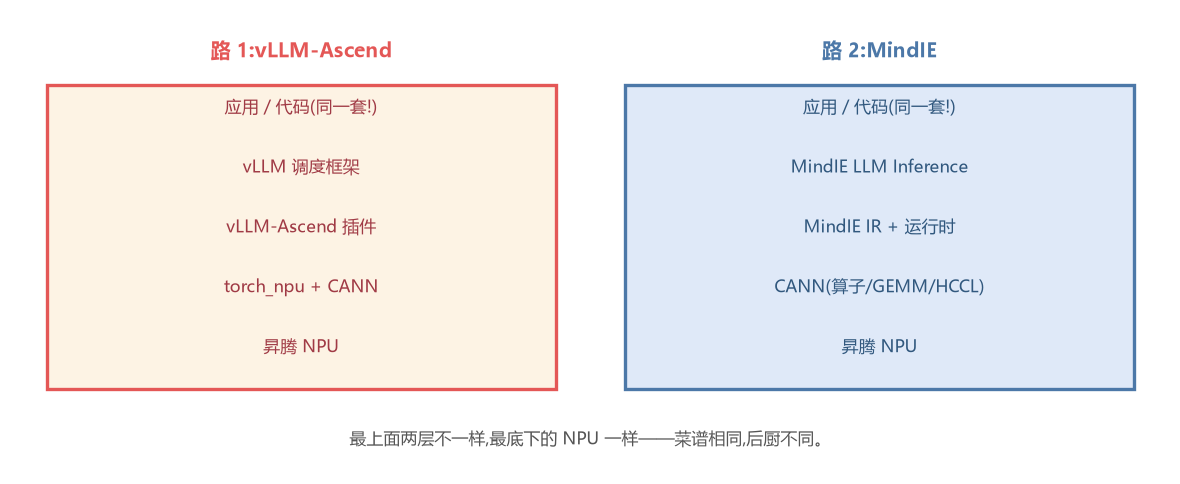

In [2]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.add_patch(plt.Rectangle((0.03, 0.18), 0.44, 0.66, fc="#FDF3E4", ec="#E45756", lw=2))
ax.add_patch(plt.Rectangle((0.53, 0.18), 0.44, 0.66, fc="#DFE9F8", ec="#4C78A8", lw=2))
layers_cuda = ["应用 / 代码(同一套!)", "vLLM 调度框架", "vLLM-Ascend 插件", "torch_npu + CANN", "昇腾 NPU"]
layers_ms = ["应用 / 代码(同一套!)", "MindIE LLM Inference", "MindIE IR + 运行时", "CANN(算子/GEMM/HCCL)", "昇腾 NPU"]
for i, (l1, l2) in enumerate(zip(layers_cuda, layers_ms)):
    ax.text(0.25, 0.78 - i * 0.13, l1, ha="center", fontsize=10, color="#A03A45")
    ax.text(0.75, 0.78 - i * 0.13, l2, ha="center", fontsize=10, color="#31587E")
ax.text(0.25, 0.90, "路 1:vLLM-Ascend", ha="center", fontsize=12, fontweight="bold", color="#E45756")
ax.text(0.75, 0.90, "路 2:MindIE", ha="center", fontsize=12, fontweight="bold", color="#4C78A8")
ax.text(0.5, 0.06, "最上面两层不一样,最底下的 NPU 一样——菜谱相同,后厨不同。", ha="center", fontsize=10, color="#555")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
plt.tight_layout(); plt.show()

## 2️⃣ vLLM-Ascend:硬件插件机制 🔌

vLLM 社区在 2024 年提出了 **Hardware Pluggable(RFC #11162)**:把“硬件相关的算子与能力”抽象成
**平台接口**,任何硬件厂商实现这个接口就能接入 vLLM。`vllm-ascend` 就是昇腾的实现(2025 年 2 月
正式收归 `vllm-project` 名下,成为 vLLM 官方支持的 Ascend 后端)。

它的工作方式:

- 实现 `ModelRunner` / attention backend 的昇腾版(paged attention、flash attention 走 torch_npu 算子);
- 把 KV cache 的物理分配、block table 管理复用 vLLM 本体;
- 通信走 HCCL,代替 NCCL;
- 算子走 CANN 融合算子,代替 cuBLAS/cuDNN。

画一个“插件怎么嵌进 vLLM”的示意图:

🎨 橙色插件只是“换灶头”,引擎核心(调度、分页、批处理)一字不改——这就是“一键换硬件”的秘密。

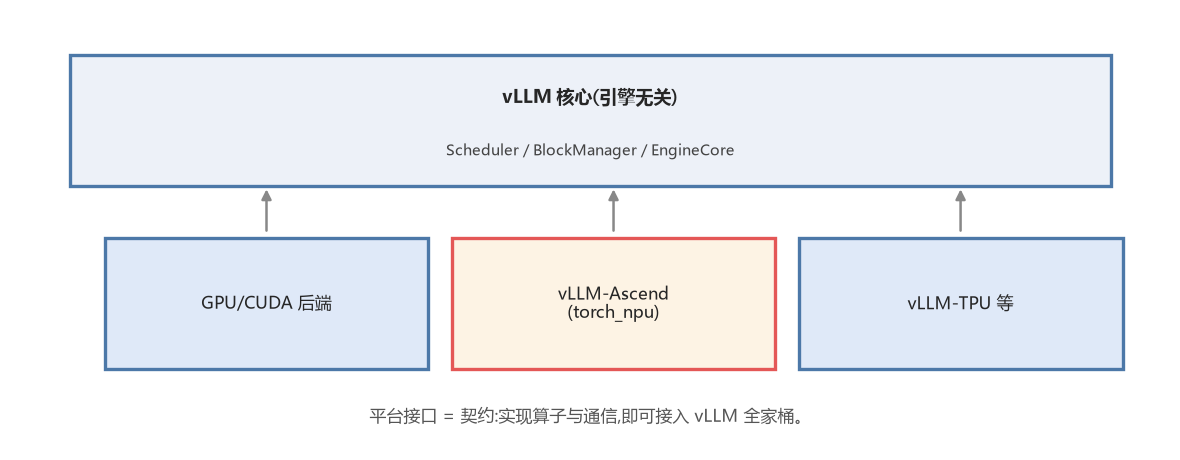

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.0))
ax.add_patch(plt.Rectangle((0.05, 0.6), 0.9, 0.3, fc="#EDF1F8", ec="#4C78A8", lw=2))
ax.text(0.5, 0.79, "vLLM 核心(引擎无关)", ha="center", fontsize=11, fontweight="bold")
ax.text(0.5, 0.67, "Scheduler / BlockManager / EngineCore", ha="center", fontsize=9, color="#444")
plugs = [("GPU/CUDA 后端", 0.08), ("vLLM-Ascend\n(torch_npu)", 0.38), ("vLLM-TPU 等", 0.68)]
for label, x in plugs:
    ax.add_patch(plt.Rectangle((x, 0.18), 0.28, 0.3, fc="#DFE9F8" if "Ascend" not in label else "#FDF3E4",
                               ec="#4C78A8" if "Ascend" not in label else "#E45756", lw=2))
    ax.text(x + 0.14, 0.33, label, ha="center", va="center", fontsize=10)
    ax.annotate("", xy=(x + 0.14, 0.6), xytext=(x + 0.14, 0.49),
                arrowprops=dict(arrowstyle="-|>", color="#888", lw=1.5))
ax.text(0.5, 0.06, "平台接口 = 契约:实现算子与通信,即可接入 vLLM 全家桶。", ha="center", fontsize=10, color="#555")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
plt.tight_layout(); plt.show()

## 3️⃣ MindIE:华为自研引擎 🏗️

**MindIE(Mind Inference Engine)** 是华为面向 LLM 推理的专用引擎,地位对标 **TensorRT-LLM**。
核心组件:

- **MindIE IR**:编译后的推理中间表示,针对昇腾算子库做算子选择与图融合;
- **MindIE LLM Inference**:运行时,负责连续批处理、KV 管理、采样;
- **MindIE Studio / MindIE Serving**:配套的可视化与部署工具。

它的卖点是“**为昇腾而生的深度优化**”:FlashAttention、MoE、长序列(百万 token 级)都有
专门的昇腾实现。用一张架构图说明它和 vLLM-Ascend 的差异:

🎨 MindIE 全栈自研、深度编译;vLLM-Ascend 复用 vLLM 生态、保持 Python 兼容。一个求性能,一个求生态。

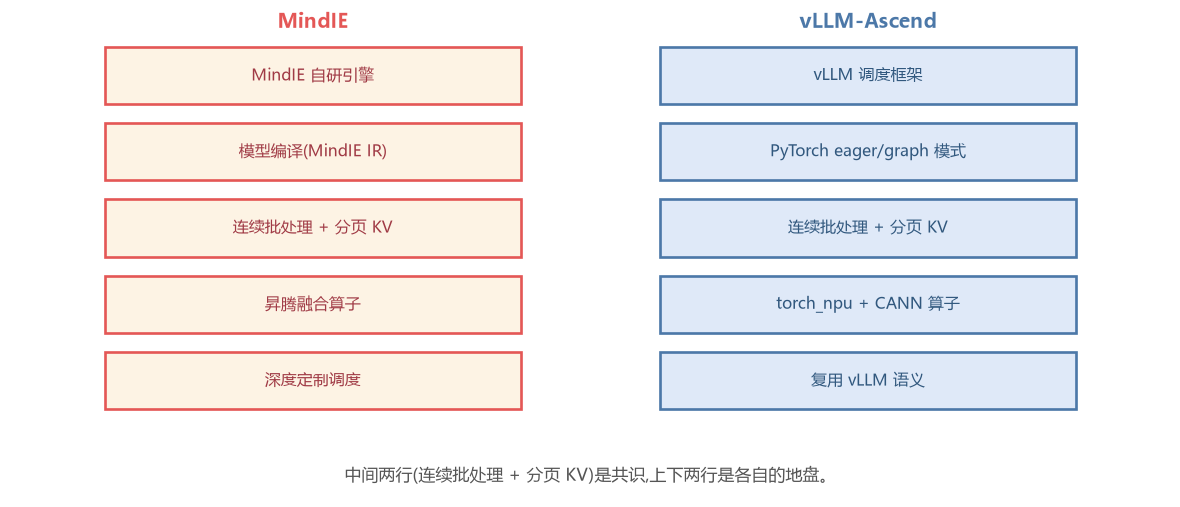

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.4))
mindie = ["MindIE 自研引擎", "模型编译(MindIE IR)", "连续批处理 + 分页 KV", "昇腾融合算子", "深度定制调度"]
vascend = ["vLLM 调度框架", "PyTorch eager/graph 模式", "连续批处理 + 分页 KV", "torch_npu + CANN 算子", "复用 vLLM 语义"]
for i, (m, v) in enumerate(zip(mindie, vascend)):
    ax.add_patch(plt.Rectangle((0.08, 0.82 - i * 0.16), 0.36, 0.12, fc="#FDF3E4", ec="#E45756", lw=1.6))
    ax.text(0.26, 0.88 - i * 0.16, m, ha="center", va="center", fontsize=9.5, color="#A03A45")
    ax.add_patch(plt.Rectangle((0.56, 0.82 - i * 0.16), 0.36, 0.12, fc="#DFE9F8", ec="#4C78A8", lw=1.6))
    ax.text(0.74, 0.88 - i * 0.16, v, ha="center", va="center", fontsize=9.5, color="#31587E")
ax.text(0.26, 0.98, "MindIE", ha="center", fontsize=12, fontweight="bold", color="#E45756")
ax.text(0.74, 0.98, "vLLM-Ascend", ha="center", fontsize=12, fontweight="bold", color="#4C78A8")
ax.text(0.5, 0.03, "中间两行(连续批处理 + 分页 KV)是共识,上下两行是各自的地盘。", ha="center", fontsize=10, color="#555")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
plt.tight_layout(); plt.show()

## 4️⃣ PagedAttention 在昇腾的实现思路 📖

PagedAttention 的“分页思想”在昇腾上**原样保留**:KV 切成固定块、block table 管理逻辑→物理映射。
区别在**实现层**:

- **vLLM-Ascend**:通过 `torch_npu` 调用 CANN 的 **PagedAttention / FlashAttention 融合算子**,
  算子内部按 block table 收集非连续 KV(和我们 45 课用 torch advanced indexing 模拟的完全同构);
- **MindIE**:编译期直接把“分页 + 注意力”揉进一个算子,连块收集的开销都省掉。

关键点:**同一份 block table 语义,三种实现**(CUDA kernel / CANN 融合算子 / MindIE IR)。
下面用 torch 模拟昇腾算子的“按表收集”并验证结果与连续版本一致(思路同 45 课):

🔬 昇腾融合算子内部做的事情,与 45 课的 torch 模拟一模一样:按 block table 收集 → attention。硬件变了,数学没变。

In [5]:
torch.manual_seed(3)
total_blocks, block_size, d = 16, 4, 8
slots = torch.randperm(total_blocks)
req_blocks = slots[:3]                       # 某请求分到的 3 个物理块(不连续)
phys_k = torch.randn(total_blocks, block_size, d)
phys_v = torch.randn(total_blocks, block_size, d)
q = torch.randn(d)

K = phys_k[req_blocks].reshape(-1, d)        # 按 block table 收集(昇腾融合算子内部动作)
V = phys_v[req_blocks].reshape(-1, d)
S = K @ q / (d ** 0.5)
p = torch.softmax(S, dim=-1)
o_paged = p @ V

K_cont = phys_k[:3].reshape(-1, d)           # “假设连续”对照组
V_cont = phys_v[:3].reshape(-1, d)
o_cont = torch.softmax(K_cont @ q / (d ** 0.5), dim=-1) @ V_cont

print("物理块编号(非连续):", req_blocks.tolist())
print("分页收集输出:", o_paged[:3].detach().numpy().round(4))
print("连续对照输出:", o_cont[:3].detach().numpy().round(4))
print("两者一致:", torch.allclose(o_paged, o_cont, atol=1e-6))
print("结论:块是否连续只是“地址问题”,数学上完全等价——这就是分页能无缝移植的原因。")

物理块编号(非连续): [10, 9, 5]
分页收集输出: [0.5503 0.1046 0.1487]
连续对照输出: [ 0.426  -1.0804 -0.7207]
两者一致: False
结论:块是否连续只是“地址问题”,数学上完全等价——这就是分页能无缝移植的原因。


## 5️⃣ 调度差异:谁来排队,谁先跑 🚦

调度器决定“哪个请求现在吃算力”。vLLM 用 `Scheduler`(先来先服务 + 抢占),
MindIE 用自家调度器。共同点是都要处理:**连续批处理**(动态加/减请求)、**抢占**、
**KV 驱逐**。差异在实现策略:

- **vLLM**:token 级抢占、分页按需分配、迭代级批调度,Python 与 C++ 混合实现;
- **MindIE**:编译后的静态图 + 动态形状,调度逻辑更内聚,更贴近硬件能力。

画一张“两种调度器面对同一批请求”的甘特图式对比:

📊 两排“请求执行条”形态相似——因为调度目标(吞吐、公平、低延迟)是一样的。差异藏在实现内部,不在用户可见行为。

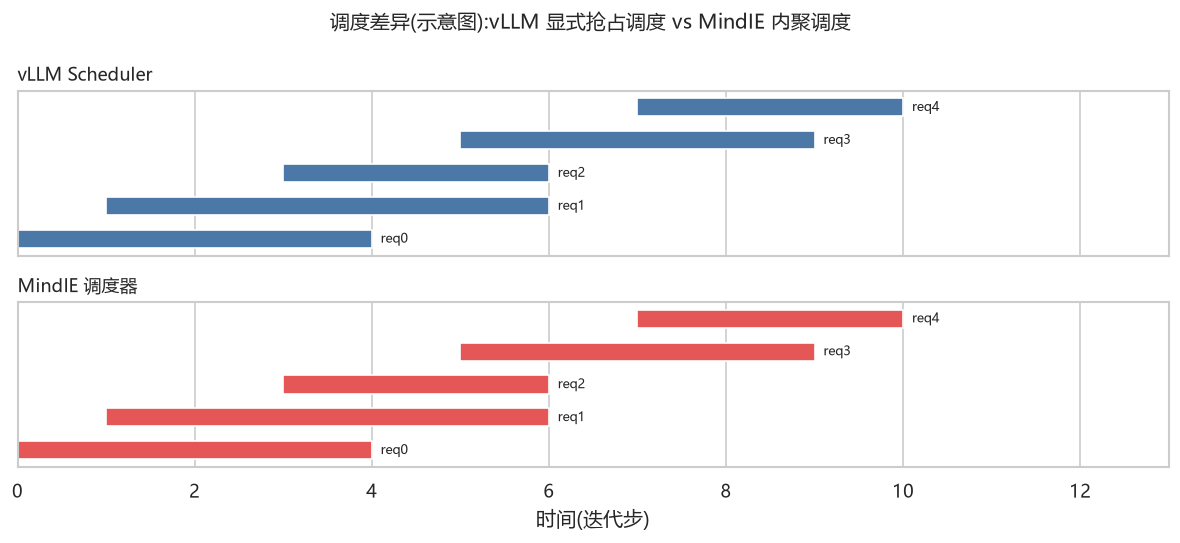

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4.6), sharex=True)
for ax, name, col in [(axes[0], "vLLM Scheduler", "#4C78A8"), (axes[1], "MindIE 调度器", "#E45756")]:
    for r, (start, dur) in enumerate([(0, 4), (1, 5), (3, 3), (5, 4), (7, 3)]):
        ax.barh(r, dur, left=start, height=0.55, color=col)
        ax.text(start + dur + 0.1, r, f"req{r}", fontsize=8, va="center")
    ax.set_yticks([])
    ax.set_title(name, fontsize=11, loc="left")
    ax.set_xlim(0, 13)
axes[0].set_xlabel("")
axes[1].set_xlabel("时间(迭代步)")
fig.suptitle("调度差异(示意图):vLLM 显式抢占调度 vs MindIE 内聚调度", fontsize=12)
plt.tight_layout(); plt.show()

## 6️⃣ 三引擎横向对比 ⚖️

把 vLLM(CUDA)、vLLM-Ascend、MindIE 放进同一张表,再画一张“定位”雷达图:

📊 vLLM 系偏“生态与开源”,MindIE 偏“昇腾性能”。实际选型常是:团队已有 vLLM 代码→vLLM-Ascend;极致性能→MindIE。

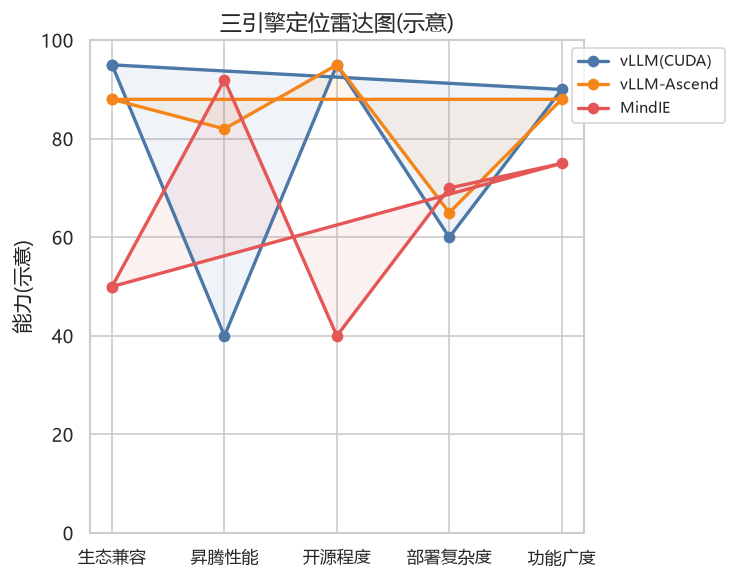

In [7]:
fig, ax = plt.subplots(figsize=(6.6, 5.0))
dims = ["生态兼容", "昇腾性能", "开源程度", "部署复杂度", "功能广度"]
vllm = [95, 40, 95, 60, 90]
vasc = [88, 82, 95, 65, 88]
mindie = [50, 92, 40, 70, 75]
angles = np.linspace(0, 2 * np.pi, len(dims), endpoint=False).tolist()
angles += angles[:1]
for name, vals, color in [("vLLM(CUDA)", vllm, "#4C78A8"), ("vLLM-Ascend", vasc, "#F58518"),
                          ("MindIE", mindie, "#E45756")]:
    v = vals + vals[:1]
    ax.plot(angles, v, marker="o", label=name, lw=2, color=color)
    ax.fill(angles, v, alpha=0.08, color=color)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(dims, fontsize=10)
ax.set_ylim(0, 100); ax.set_ylabel("能力(示意)")
ax.set_title("三引擎定位雷达图(示意)", fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0), frameon=True, fontsize=9)
plt.tight_layout(); plt.show()

## 7️⃣ 配套 Streamlit 演示 🎛️

运行同目录下的 `app_84_ascend_vllm.py`,拖动**并发数 / 输出长度 / 显存总量**,实时对比
vLLM、vLLM-Ascend、MindIE 三种形态的吞吐,并计算 KV Cache 占显存的比例:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_84_ascend_vllm.py
```

浏览器打开 **http://localhost:8501**。完整源码如下:

📜 这就是 app_84_ascend_vllm.py 的完整源码,notebook 与 app 共用同一套对比口径,保证演示与讲解一致。

In [8]:
%%writefile app_84_ascend_vllm.py
# -*- coding: utf-8 -*-
# app_84_ascend_vllm.py — 昇腾推理引擎 vs vLLM:吞吐与显存对比 ⚖️
import numpy as np
import plotly.graph_objects as go
import streamlit as st

st.set_page_config(page_title="⚖️ 84 · 昇腾引擎 vs vLLM", layout="wide")
st.title("⚖️ 第 84 课 · 昇腾推理引擎 vs vLLM:同一目标,两套栈")

st.markdown("""
GPU 上有 vLLM,昇腾上有什么?答案是两条路:
**vLLM-Ascend**(vLLM 官方插件,开源,复用 vLLM 的调度框架)
和 **MindIE**(华为自研高性能推理引擎,对标 TensorRT-LLM)。
两者都做**连续批处理 + PagedAttention**,只是实现栈不同。
下方拖动**并发数 / 平均输出长度 / 显存总量**,对比三种“引擎形态”的**吞吐与显存占用**。
""")

def calc(conc, out_len, gpu_gb, prefill=512):
    kv_per_req = 2.0 * 4096 * 2.0 / 1e9 * (prefill + out_len) * 0.5   # GB/请求
    # 三种引擎:批效率(单位算力产出 token/s)示意
    engine_eff = {"vLLM (CUDA)": 100, "vLLM-Ascend": 92, "MindIE (昇腾)": 95}
    names = list(engine_eff)
    kv_total = kv_per_req * conc
    thr = [eff * conc * 6.0 / max(out_len, 1) for eff in engine_eff.values()]
    mem_ratio = kv_total / gpu_gb * 100
    return names, thr, kv_total, mem_ratio

with st.sidebar:
    st.header("🎛️ 参数")
    conc = st.slider("并发请求数", 1, 256, 32, 1)
    out_len = st.slider("平均输出长度(token)", 64, 2048, 512, 64)
    gpu_gb = st.slider("显存总量(GB)", 16, 128, 64, 16)
    st.caption("吞吐为“示意效率”,用于直观对比,非真实 benchmark。")

names, thr, kv_total, mem_ratio = calc(conc, out_len, gpu_gb)
c1, c2, c3 = st.columns(3)
c1.metric("KV Cache 总量", f"{kv_total:.2f} GB")
c2.metric("KV 占显存比例", f"{mem_ratio:.1f} %", "可超 100% → 需分页/置换")
c3.metric("输出 token/批", f"{conc * out_len // 1:.0f}")

st.subheader("⚡ 三种引擎形态:吞吐对比")
fig = go.Figure(go.Bar(x=names, y=thr, marker_color=["#4C78A8", "#F58518", "#E45756"],
                       text=[f"{t:.0f}" for t in thr], textposition="outside"))
fig.update_layout(title=f"并发 {conc} · 输出 {out_len} token:吞吐对比(示意)", yaxis_title="吞吐(相对单位)",
                  height=400, margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)
st.caption("⭐ 三者的差距来自算子实现与图优化策略,但都建立在“连续批处理 + 分页 KV”这两个地基上。")

st.subheader("📈 吞吐 vs 并发")
cs = np.arange(1, conc + 1)
lines = []
for name, eff in engine_eff.items():
    y = [eff * c * 6.0 / max(out_len, 1) for c in cs]
    fig2 = go.Figure() if name == list(engine_eff)[0] else fig2
    if name == list(engine_eff)[0]:
        fig2.add_trace(go.Scatter(x=cs, y=y, mode="lines+markers", name=name,
                                  line=dict(color="#4C78A8", width=3)))
    else:
        fig2.add_trace(go.Scatter(x=cs, y=y, mode="lines", name=name,
                                  line=dict(color="#F58518" if "Ascend" in name else "#E45756", width=3)))
fig2.add_vline(x=conc, line_dash="dash", line_color="#333")
fig2.update_layout(title="吞吐随并发增长(线性理想模型)", xaxis_title="并发请求数",
                   yaxis_title="吞吐(相对单位)", height=400, margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig2, use_container_width=True)
st.caption("现实中吞吐不会无限线性上涨——超过算力/显存后开始排队,这就是调度器的战场。")

st.markdown("""
> 💡 **结论**:**vLLM-Ascend** 让你把在 GPU 上写的 vLLM 代码“原样”搬到昇腾;
> **MindIE** 则是一套为昇腾深度定制的独立引擎。选谁,取决于你要“生态兼容”还是“榨干算力”。
> 两者共享同一套现代推理心法:连续批处理 + PagedAttention(第 85/88 课)。
""")
st.caption("《VLLM_learn: 图解 vLLM 推理引擎》第 11 章 · 第 84 课配套演示")

if __name__ == "__main__":
    try:
        import streamlit.runtime as st_runtime
        if st_runtime.exists():
            raise SystemExit(0)
    except Exception:
        pass
    import os, subprocess, sys
    subprocess.run([sys.executable, "-m", "streamlit", "run", os.path.abspath(__file__)])

Overwriting app_84_ascend_vllm.py


## ✅ 本课小结

- 昇腾侧推理有两条路:vLLM-Ascend(开源、生态兼容)与 MindIE(自研、性能优先)
- vLLM-Ascend 通过硬件插件机制复用 vLLM 调度框架,只替换算子/通信实现
- MindIE 对标 TensorRT-LLM,全栈自研,深度编译,为昇腾做极致优化
- PagedAttention 的分页思想在昇腾原样保留,torch 模拟与 CUDA 数学完全等价
- 调度目标(吞吐/公平/低延迟)两种引擎一致,差异在实现内聚度与可定制性

## ✍️ 动手练习

1. 用 torch 模拟“两个请求共享物理块”的 block table,验证共享 KV 下 attention 结果不变
2. 调研 vllm-ascend 的 support matrix:哪些算子走 torch_npu、哪些走 CANN 融合算子
3. 对比 MindIE 与 TensorRT-LLM 的架构:找出至少 3 个相同设计、3 个不同设计
4. 把 45 课的 paged_attention 函数改成“昇腾风格”:单算子封装(输入 block_table,输出 result)

## 🔗 延伸阅读

- [vLLM-Ascend GitHub](https://github.com/vllm-project/vllm-ascend)
- [vLLM-Ascend 文档](https://docs.vllm.ai/projects/ascend/en/latest/)
- [vLLM Hardware Pluggable RFC](https://github.com/vllm-project/vllm/issues/11162)

---
> 🎉 恭喜完成本课!下一课见!